In [1]:
import sys
sys.path.append("..")

from datetime import datetime
import jax
from jax import flatten_util, vmap 
import jax.numpy as jnp
import jax.random as jr
import os
import matplotlib.pyplot as plt
from physical_diffusion_fns.helper_fns import sample_gaussian_mixture, sample_forward_process, interpolate_parameters
from physical_diffusion_fns.learning_fns import run_optimization, setup_score_matching_kbT_loss_analytical
from physical_diffusion_fns.plotting_fns import plot_energy_and_distributions, plot_parameter_evolution, plot_forward_marginals, visualize_connectivity, plot_parameter_as_fn_of_time, plot_sampels_energy_marginals_for_SGM_vs_ES
from physical_diffusion_fns.network_fns import setup_overdamped_SDE, solve_SDE, setup_energy_fn, setup_duffing_network_analytical_derivatives

jax.config.update("jax_enable_x64", True) 

2026-02-19 20:45:00.944685: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.9.86. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


# Random keys

In [2]:
master_key  = jax.random.PRNGKey(0)          # single seed
sample_target_key, optimization_key, reverse_sde_key = jr.split(master_key, 3)

# Generate samples from a mixture of 2 Gaussians in 2d - the target distribution

In [3]:
# Parameters
N = 2  # number of dimensions
N_mixgauss = 3  # number of mixture components
n_samples = 10000

# Define mixture weights (must sum to 1)
weights = jnp.array([.6, .4])

# Define means
means = jnp.array([
    [1., 0.5],   # mean of first Gaussian
    [-1., -0.5],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[0.001, 0.0],    # covariance of first Gaussian
        [0.0, 0.001]],
    [[0.001, 0.0],   # covariance of second Gaussian
        [0.0, 0.001]],
])
# Generate samples
samples_target = sample_gaussian_mixture(sample_target_key, n_samples, weights, means, covs)
# Normalize samples
# samples = normalize_samples(samples_raw)

### Plot samples and marginal of target distributions

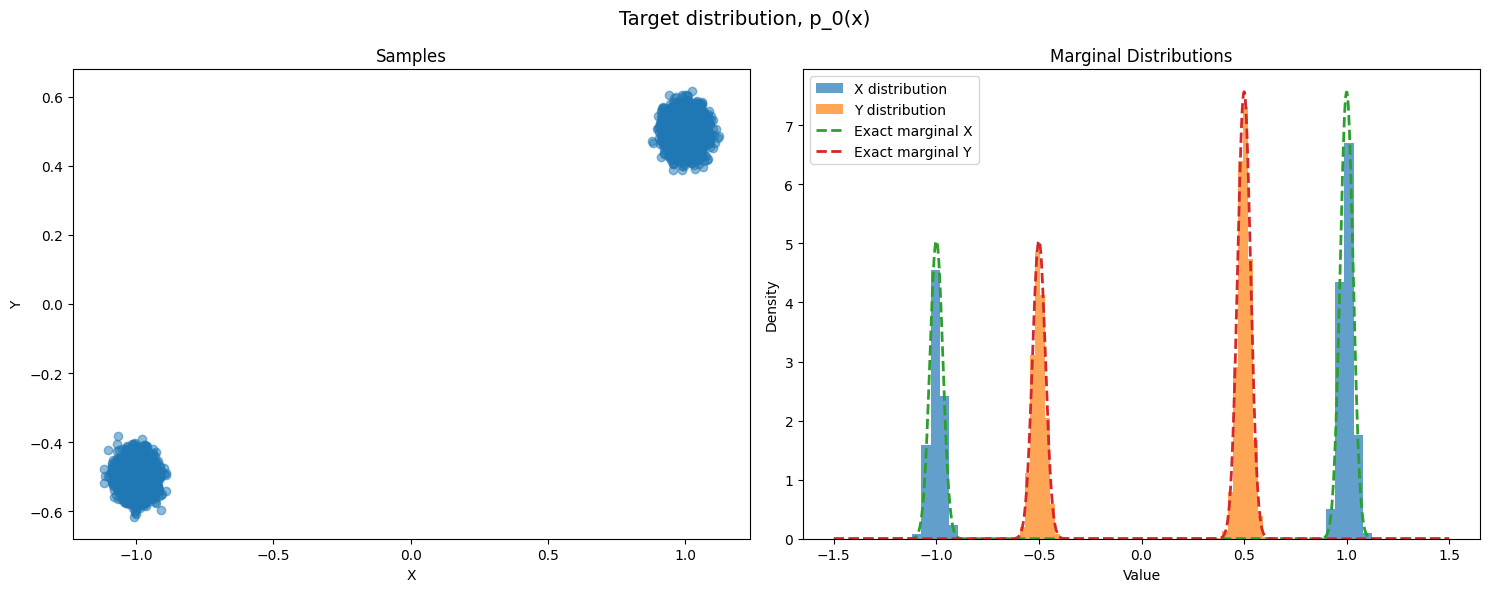

In [4]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Target distribution, p_0(x)', fontsize=14)

# First subplot: Scatter plot of samples
ax1.scatter(samples_target[:, 0], samples_target[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_target[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_target[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')

# Add exact marginal Gaussians
x = jnp.linspace(-1.5, 1.5, 1000)
for dim in range(2):
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax2.plot(x, marginal, '--', linewidth=2, label=f'Exact marginal {["X", "Y"][dim]}')

ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

# Physical system

## Network size, topology and temperature

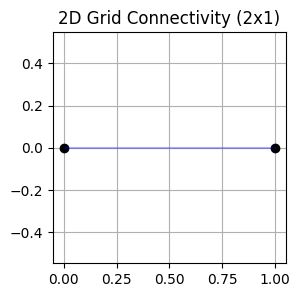

In [5]:
Temp = 0.2
N_osc = 2
connectivity = jnp.array([[0, 1]])
num_connections = connectivity.shape[0]
visualize_connectivity(connectivity,grid_size_x=2,grid_size_y=1)

## Energy
Up to 6th order local energies and up to 4th order coupling energies

In [6]:
k_lin_0 = -1.*jnp.ones(N_osc)
k_duff_0 = jnp.ones(N_osc)
k_6_0 = jnp.ones(N_osc)
c_lin_0 = jnp.zeros(num_connections)
c_optomech_0 = jnp.zeros(num_connections)
c_duff_0 = jnp.zeros(num_connections)
biases_0 = jnp.zeros(N_osc)
params_initial = (k_lin_0, k_duff_0, k_6_0, c_lin_0, c_optomech_0, c_duff_0, biases_0)
params_names = ['k_lin', 'k_duff', 'k_6', 'c_lin', 'c_optomech', 'c_duff', 'biases']
params_flattened_initial, unflatten = flatten_util.ravel_pytree(params_initial)
constraint_indices_k6_self = jnp.arange(2*N_osc,3*N_osc)
constraint_indices = constraint_indices_k6_self

# Set up energy fn
energy_fn = setup_energy_fn(connectivity, unflatten)
# Set up analytical derivatives
gradient_fn, trace_hessian_fn, gradient_wrt_params_fn, trace_hessian_wrt_params_fn = setup_duffing_network_analytical_derivatives(connectivity, unflatten)

### Plot initial energy landscape

Initial Parameters probability distribution total (should be ≈ 1): 1.000000


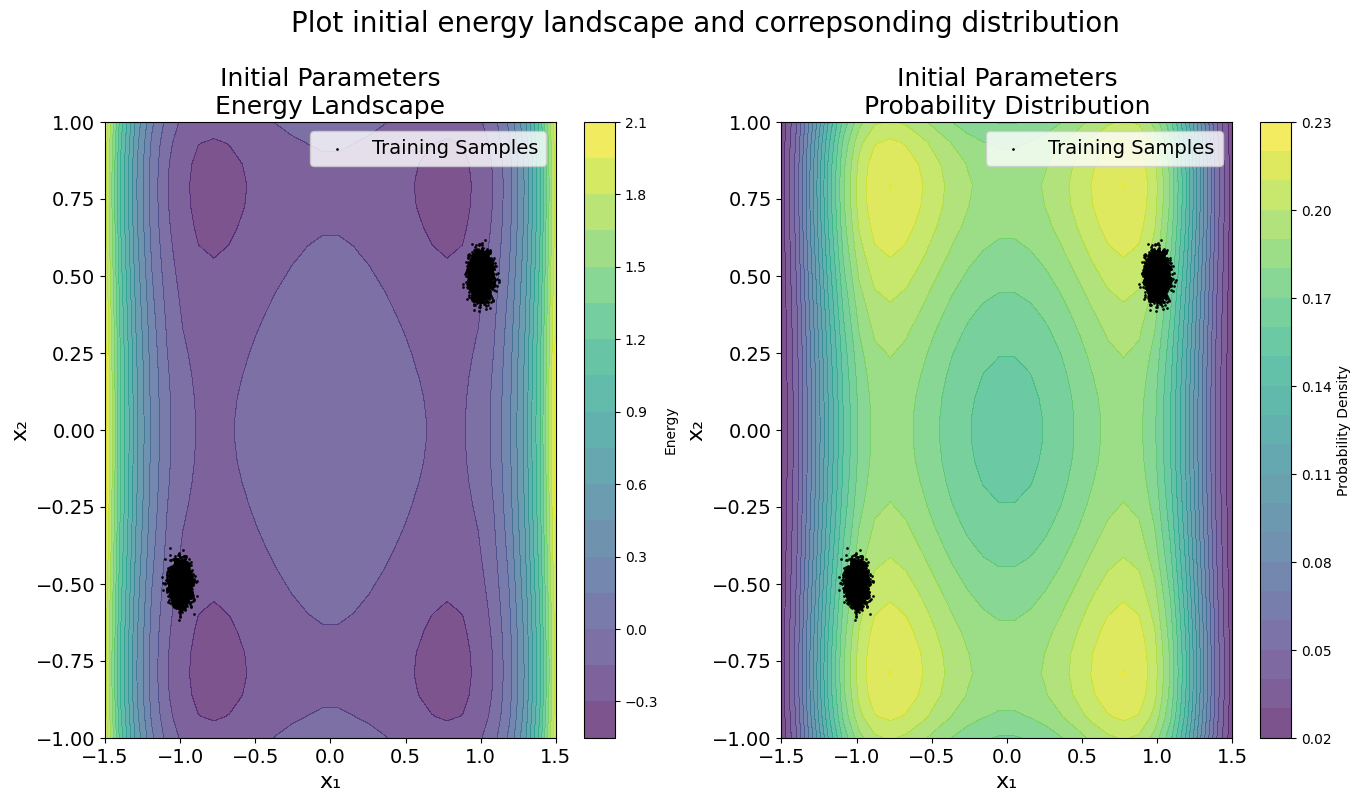

In [7]:
# Example usage:
param_list = [params_flattened_initial]
titles = ["Initial Parameters"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples_target,
    x1_range=(-1.5, 1.5),   
    x2_range=(-1, 1),   
    n_points=30,       
    titles=titles,      
    figsize=(16, 8),   
    fontsize=16,        
    sample_stride=1,
    suptitle="Plot initial energy landscape and correpsonding distribution" 
)

# Learning

In [8]:
# Use analytical version for much better performance
loss_fn_per_batch, gradient_fn_per_batch = setup_score_matching_kbT_loss_analytical(
    gradient_fn, trace_hessian_fn, gradient_wrt_params_fn, trace_hessian_wrt_params_fn, 
    k_b=1.0, T=Temp
)
maximize = False
learning_rate = 0.1*Temp

#### Optimization parameters and filenames

In [9]:
# Forward process parameters
n_time_steps = 5
t_forward = 5.
forward_time_pts = jnp.linspace(0., t_forward, n_time_steps)

# Optimization parameters
n_epochs = 100000
batch_size = 16*128
window_size=500
tolerance=1e-1
patience=100

In [10]:
problem_type_folder = f"gaussian_mixture/Energy_fn_type_6th_order_local_duffing_coupling_Temp_{Temp}"
optimization_folder = (
     f"t_forward_{t_forward}_"
     f"n_timesteps_{n_time_steps}_"
        f"lr_{learning_rate}_"
        f"epochs_{n_epochs}_"
        f"batch_{batch_size}_"
        f"window_{window_size}_"
        f"tol_{tolerance}_"
        f"patience_{patience}")

# Setup output directories
# here = os.path.dirname(os.path.abspath(__file__))
current_date = datetime.now().strftime("%Y_%m_%d")

base_dir = "../out/problems"
output_dir = os.path.join(base_dir, current_date,problem_type_folder, f"weights_{weights}_means_{means.flatten()}_covs_{covs.flatten()}", optimization_folder)
plot_folder = os.path.join(output_dir, 'aaa_final_plots')

# Create directories if they don't exist
os.makedirs(output_dir, exist_ok=True)
os.makedirs(plot_folder, exist_ok=True)
print(f"Output directory: {output_dir}")
print(f"Plot directory: {plot_folder}")

save_fig = False

Output directory: ../out/problems/2026_02_19/gaussian_mixture/Energy_fn_type_6th_order_local_duffing_coupling_Temp_0.2/weights_[0.6 0.4]_means_[ 1.   0.5 -1.  -0.5]_covs_[0.001 0.    0.    0.001 0.001 0.    0.    0.001]/t_forward_5.0_n_timesteps_5_lr_0.020000000000000004_epochs_100000_batch_2048_window_500_tol_0.1_patience_100
Plot directory: ../out/problems/2026_02_19/gaussian_mixture/Energy_fn_type_6th_order_local_duffing_coupling_Temp_0.2/weights_[0.6 0.4]_means_[ 1.   0.5 -1.  -0.5]_covs_[0.001 0.    0.    0.001 0.001 0.    0.    0.001]/t_forward_5.0_n_timesteps_5_lr_0.020000000000000004_epochs_100000_batch_2048_window_500_tol_0.1_patience_100/aaa_final_plots


No existing parameters found, running optimization
t_idx: 0, t_curr: 0.0


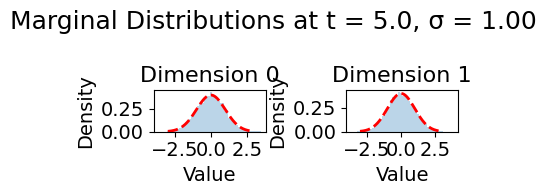

Epoch 0 - Loss: -20.6328 - Best Loss: -20.6328 (Epoch 0)
Epoch 100 - Loss: -91.5211 - Best Loss: -91.5211 (Epoch 100)
Epoch 200 - Loss: -152.2228 - Best Loss: -152.2228 (Epoch 200)
Epoch 300 - Loss: -203.7086 - Best Loss: -204.6324 (Epoch 299)
Epoch 400 - Loss: -248.3371 - Best Loss: -248.3371 (Epoch 400)
Epoch 500 - Loss: -287.4994 - Best Loss: -287.4994 (Epoch 500)
Epoch 600 - Loss: -318.8767 - Best Loss: -319.2730 (Epoch 596)
Epoch 700 - Loss: -347.5644 - Best Loss: -349.3595 (Epoch 698)
Epoch 800 - Loss: -375.2847 - Best Loss: -375.2847 (Epoch 800)
Epoch 900 - Loss: -394.8531 - Best Loss: -394.8531 (Epoch 900)
Epoch 1000 - Loss: -414.1021 - Best Loss: -415.2779 (Epoch 988)
Epoch 1100 - Loss: -434.3739 - Best Loss: -434.3739 (Epoch 1100)
Epoch 1200 - Loss: -445.1687 - Best Loss: -451.7823 (Epoch 1199)
Epoch 1300 - Loss: -461.4305 - Best Loss: -461.4305 (Epoch 1300)
Epoch 1400 - Loss: -468.4393 - Best Loss: -474.6503 (Epoch 1397)
Epoch 1500 - Loss: -482.4689 - Best Loss: -482.7485 (E

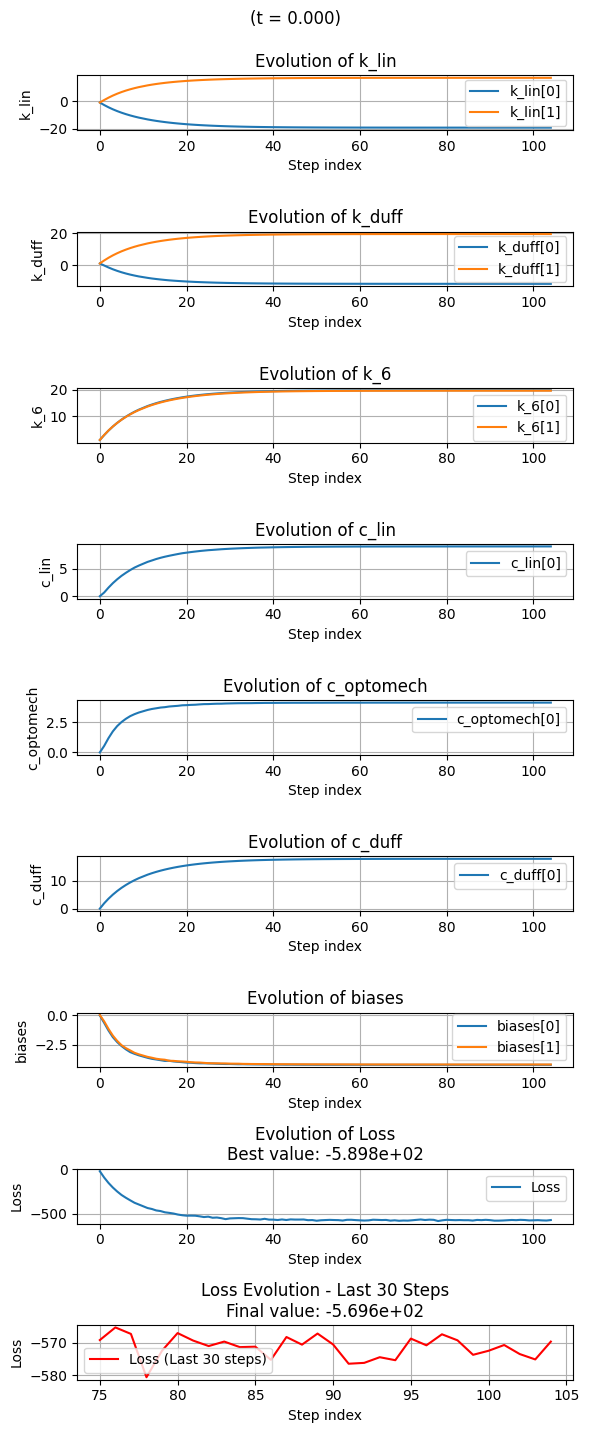

t_idx: 1, t_curr: 1.25
Epoch 0 - Loss: 36691.2769 - Best Loss: 36691.2769 (Epoch 0)
Epoch 100 - Loss: 34407.1921 - Best Loss: 19255.9539 (Epoch 82)
Epoch 200 - Loss: 15610.8163 - Best Loss: 15239.0924 (Epoch 154)
Epoch 300 - Loss: 13745.8907 - Best Loss: 11151.9813 (Epoch 279)
Epoch 400 - Loss: 9775.1602 - Best Loss: 8764.5379 (Epoch 388)
Epoch 500 - Loss: 17326.7331 - Best Loss: 7844.7104 (Epoch 436)
Epoch 600 - Loss: 7502.3474 - Best Loss: 6038.9604 (Epoch 598)
Epoch 700 - Loss: 8319.6526 - Best Loss: 5098.7477 (Epoch 694)
Epoch 800 - Loss: 6180.0848 - Best Loss: 4601.7564 (Epoch 789)
Epoch 900 - Loss: 4197.5977 - Best Loss: 3878.4387 (Epoch 845)
Epoch 1000 - Loss: 4263.1002 - Best Loss: 3347.4337 (Epoch 998)
Epoch 1100 - Loss: 3849.9661 - Best Loss: 3230.0278 (Epoch 1070)
Epoch 1200 - Loss: 3557.2293 - Best Loss: 2526.9984 (Epoch 1152)
Epoch 1300 - Loss: 2841.4242 - Best Loss: 2446.4438 (Epoch 1230)
Epoch 1400 - Loss: 2374.6433 - Best Loss: 2235.7767 (Epoch 1366)
Epoch 1500 - Loss: 

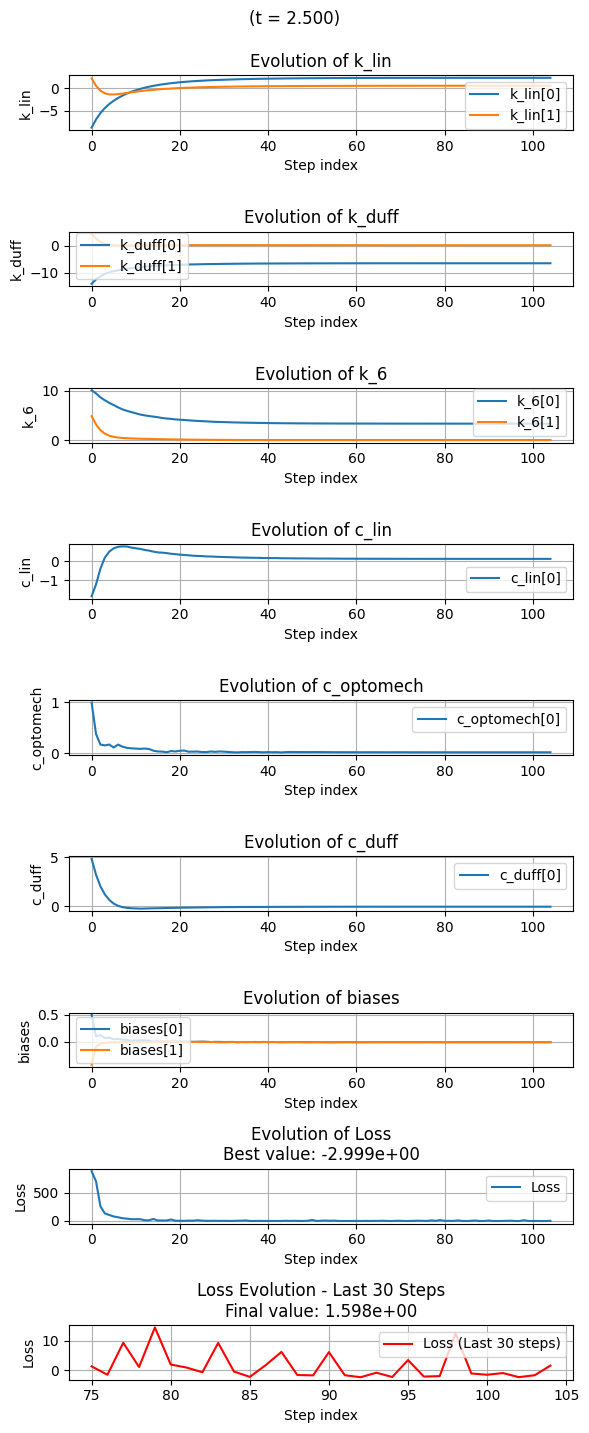

t_idx: 3, t_curr: 3.75
Epoch 0 - Loss: -2.2902 - Best Loss: -2.2902 (Epoch 0)
Epoch 100 - Loss: -2.3444 - Best Loss: -3.2444 (Epoch 27)
Epoch 200 - Loss: -2.8251 - Best Loss: -3.9845 (Epoch 197)
Epoch 300 - Loss: -3.7738 - Best Loss: -4.0400 (Epoch 264)
Epoch 400 - Loss: -4.1273 - Best Loss: -4.6595 (Epoch 374)
Epoch 500 - Loss: -4.0648 - Best Loss: -4.7588 (Epoch 469)
Epoch 600 - Loss: -4.2456 - Best Loss: -4.7770 (Epoch 578)
Epoch 700 - Loss: -4.8209 - Best Loss: -4.9199 (Epoch 640)
Epoch 800 - Loss: -4.8070 - Best Loss: -5.0321 (Epoch 770)
Epoch 900 - Loss: -4.4426 - Best Loss: -5.0321 (Epoch 770)
Epoch 1000 - Loss: -4.8138 - Best Loss: -5.1122 (Epoch 960)
Epoch 1100 - Loss: -4.8674 - Best Loss: -5.1516 (Epoch 1094)
Epoch 1200 - Loss: -4.8973 - Best Loss: -5.1516 (Epoch 1094)
Epoch 1300 - Loss: -4.9307 - Best Loss: -5.2927 (Epoch 1215)
Epoch 1400 - Loss: -4.5306 - Best Loss: -5.2927 (Epoch 1215)
Epoch 1500 - Loss: -4.8893 - Best Loss: -5.2927 (Epoch 1215)
Epoch 1600 - Loss: -4.8374 

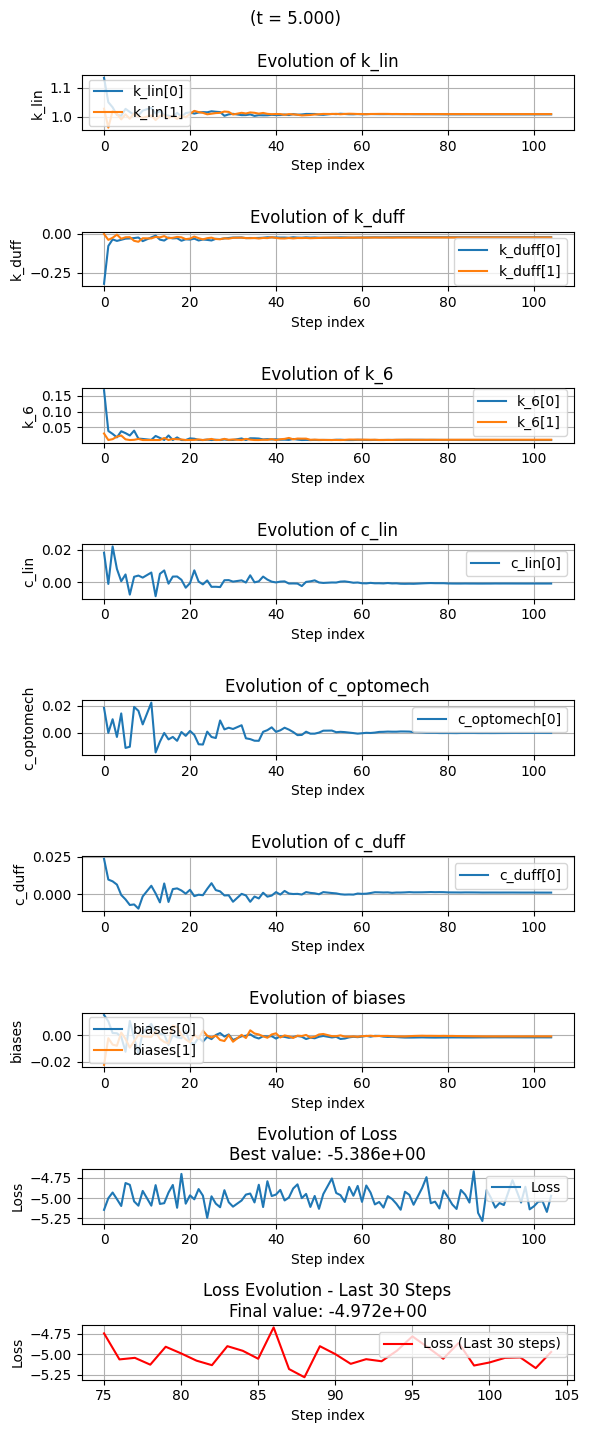

Optimization complete; saved parameters to ../out/problems/2026_02_19/gaussian_mixture/Energy_fn_type_6th_order_local_duffing_coupling_Temp_0.2/weights_[0.6 0.4]_means_[ 1.   0.5 -1.  -0.5]_covs_[0.001 0.    0.    0.001 0.001 0.    0.    0.001]/t_forward_5.0_n_timesteps_5_lr_0.020000000000000004_epochs_100000_batch_2048_window_500_tol_0.1_patience_100


In [11]:
params_history_path = f"{output_dir}/params_history.npy"
if os.path.exists(params_history_path):
    # Load existing parameters
    print('Loading existing parameters from', params_history_path)
    params_history_all_t = jnp.load(params_history_path)
else:
    print('No existing parameters found, running optimization')    

# Setup optimization parameters
mask = jnp.ones(params_flattened_initial.shape[0])

# Plotting parameters
plot_steps = True  # Flag to control whether to plot during optimization
plot_slice = 2     # Plot every nth step

params_history_all_t = []
current_params = params_flattened_initial

# Loop over time points
for t_idx, t_curr in enumerate(forward_time_pts):
    print(f"t_idx: {t_idx}, t_curr: {t_curr}")
    optimization_key, optimization_subkey = jr.split(optimization_key)
    
    if t_idx == 0:
        samples_0 = sample_forward_process(t_forward, n_samples, D=1, sigma_final=1., samples0=samples_target, key=optimization_key)
        plot_forward_marginals(samples_0, t_forward, 1., beta=1.0, path=output_dir, save_fig=save_fig, fontsize=16, plot_show=True)
    
    sampler = lambda key: sample_forward_process(
            t_curr, n_samples = batch_size, D=Temp, sigma_final=1., samples0=samples_target, key=key, beta= 1
        )
    
    # Perform optimization starting from previous best parameters
    params_history, loss_history, current_params, best_loss, best_epoch = run_optimization(
        loss_fn_per_batch=loss_fn_per_batch,
        params_initial=current_params,
        sampler=sampler,
        mask=mask,
        gradient_fn_per_batch=gradient_fn_per_batch,
        key=optimization_subkey,
        learning_rate=learning_rate,
        n_epochs=n_epochs,
        window_size=window_size,
        tolerance=tolerance,
        patience=patience,
        constraint_indices=constraint_indices
    )
    
    params_history_all_t.append(current_params)
    
    if plot_steps:
        if t_idx % plot_slice == 0:
            # Plot optimization progress
            plot_parameter_evolution(
                params_history=params_history,
                loss_history=loss_history,
                best_params=current_params,
                best_loss=best_loss,
                best_idx=best_epoch,
                time = t_curr,
                time_index = t_idx,
                unflatten=unflatten,
                N_osc=N_osc,
                title=f"(t = {t_curr:.3f})",
                maximize=maximize,
                labels_on=True,
                save_fig=save_fig,
                path=output_dir,
                param_names=params_names,
                plot_show=True
            )
        
# Convert params_history_all_t to array for easier analysis
params_history_all_t = jnp.array(params_history_all_t)
jnp.save(f"{output_dir}/params_history.npy", params_history_all_t)

print('Optimization complete; saved parameters to', output_dir)

### Interpolate and plot parameter evolution

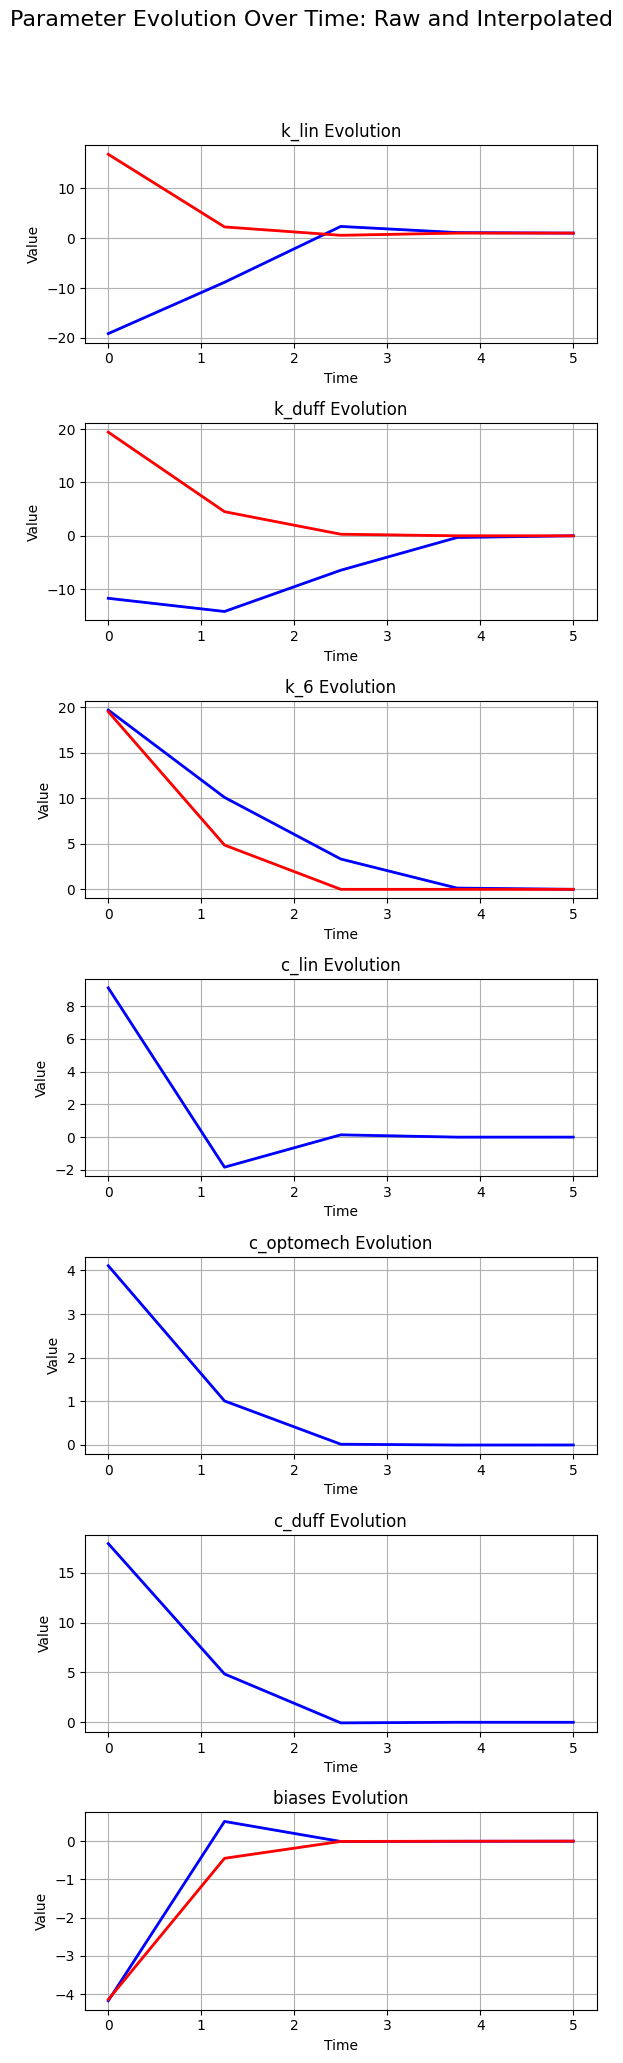

In [12]:
# Get interpolator functions
params_interpolator = interpolate_parameters(params_history_all_t, forward_time_pts)

plot_parameter_as_fn_of_time(params_names, forward_time_pts, forward_time_pts, params_history_all_t, params_interpolator, unflatten, N_osc, save_fig=True, path=plot_folder, log_scale=False,plot_show=True)


### Run reverse SDE:

In [13]:
forward_params = jnp.zeros_like(params_flattened_initial)
forward_params = forward_params.at[0:N_osc].set(1.)

params_interpolator_reverse_plus_linear = lambda t: 2*params_interpolator(t_forward - t) - forward_params


# Setup SDE functions
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator_reverse_plus_linear, N_osc, time_dependent_parms=True, Temp=Temp)

t0 = 0.0
t1 = t_forward
ts = jnp.linspace(t0, t1, 100)
dt0 = 0.00000001
atol = 1e-4
rtol = 1e-6

n_trajectories = 2000

# Generate multiple initial states from the asymptotic Gaussian N(0, Temp * I)
reverse_sde_key, subkey_initial = jr.split(reverse_sde_key)
initial_states = jnp.sqrt(Temp) * jr.normal(subkey_initial, shape=(n_trajectories, N))

# Generate a key for each initial condition
keys_brownian = jr.split(reverse_sde_key, n_trajectories)

# Vectorize solve_SDE across both initial states and keys
vectorized_solve_SDE = vmap(
    lambda init_state, key_b: solve_SDE(
        drift_fn,
        diffusion_fn,
        init_state,
        key_b,
        t0,
        t1,
        ts.shape[0],
        dt0,
        rtol=rtol,
        atol=atol
    ),
    in_axes=(0, 0)
)

# Run SDE for all initial states at once
solutions = vectorized_solve_SDE(initial_states, keys_brownian)
all_trajectories = solutions.ys
final_states = all_trajectories[:, -1, :]

/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.wa

### Run equillibirum SDE

In [14]:
t1 = n_trajectories*t_forward*0.00001
sde_samples_direct_path = f"{output_dir}/sde_samples_direct_simT_{t1}.npy"
if os.path.exists(sde_samples_direct_path):
    # Load existing parameters
    print('Loading existing equilibrium trajectory', sde_samples_direct_path)
    sde_samples_direct = jnp.load(sde_samples_direct_path)
else:
    print('No existing equilibrium trajectory found, running optimization')   
    drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator(0), N_osc, Temp=Temp, time_dependent_parms=False)
    t0 = 0.0
    ts = jnp.linspace(t0, t1, n_trajectories)
    dt0 = ts[1] - ts[0]
    initial_state = jnp.array([-.0,0.])

    reverse_sde_key, subkey_direct = jr.split(reverse_sde_key)
    solution_direct = solve_SDE(drift_fn, diffusion_fn, initial_state,subkey_direct, t0, t1, ts.shape[0], dt0,atol=atol,rtol=rtol)
    sde_samples_direct = solution_direct.ys
    jnp.save(f"{output_dir}/sde_samples_direct.npy", sde_samples_direct)


No existing equilibrium trajectory found, running optimization


/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.wa

## Plot samples

    Reverse Trajectory total prob ≈ 1.000000
  Equilibrium Sampling total prob ≈ 1.000000


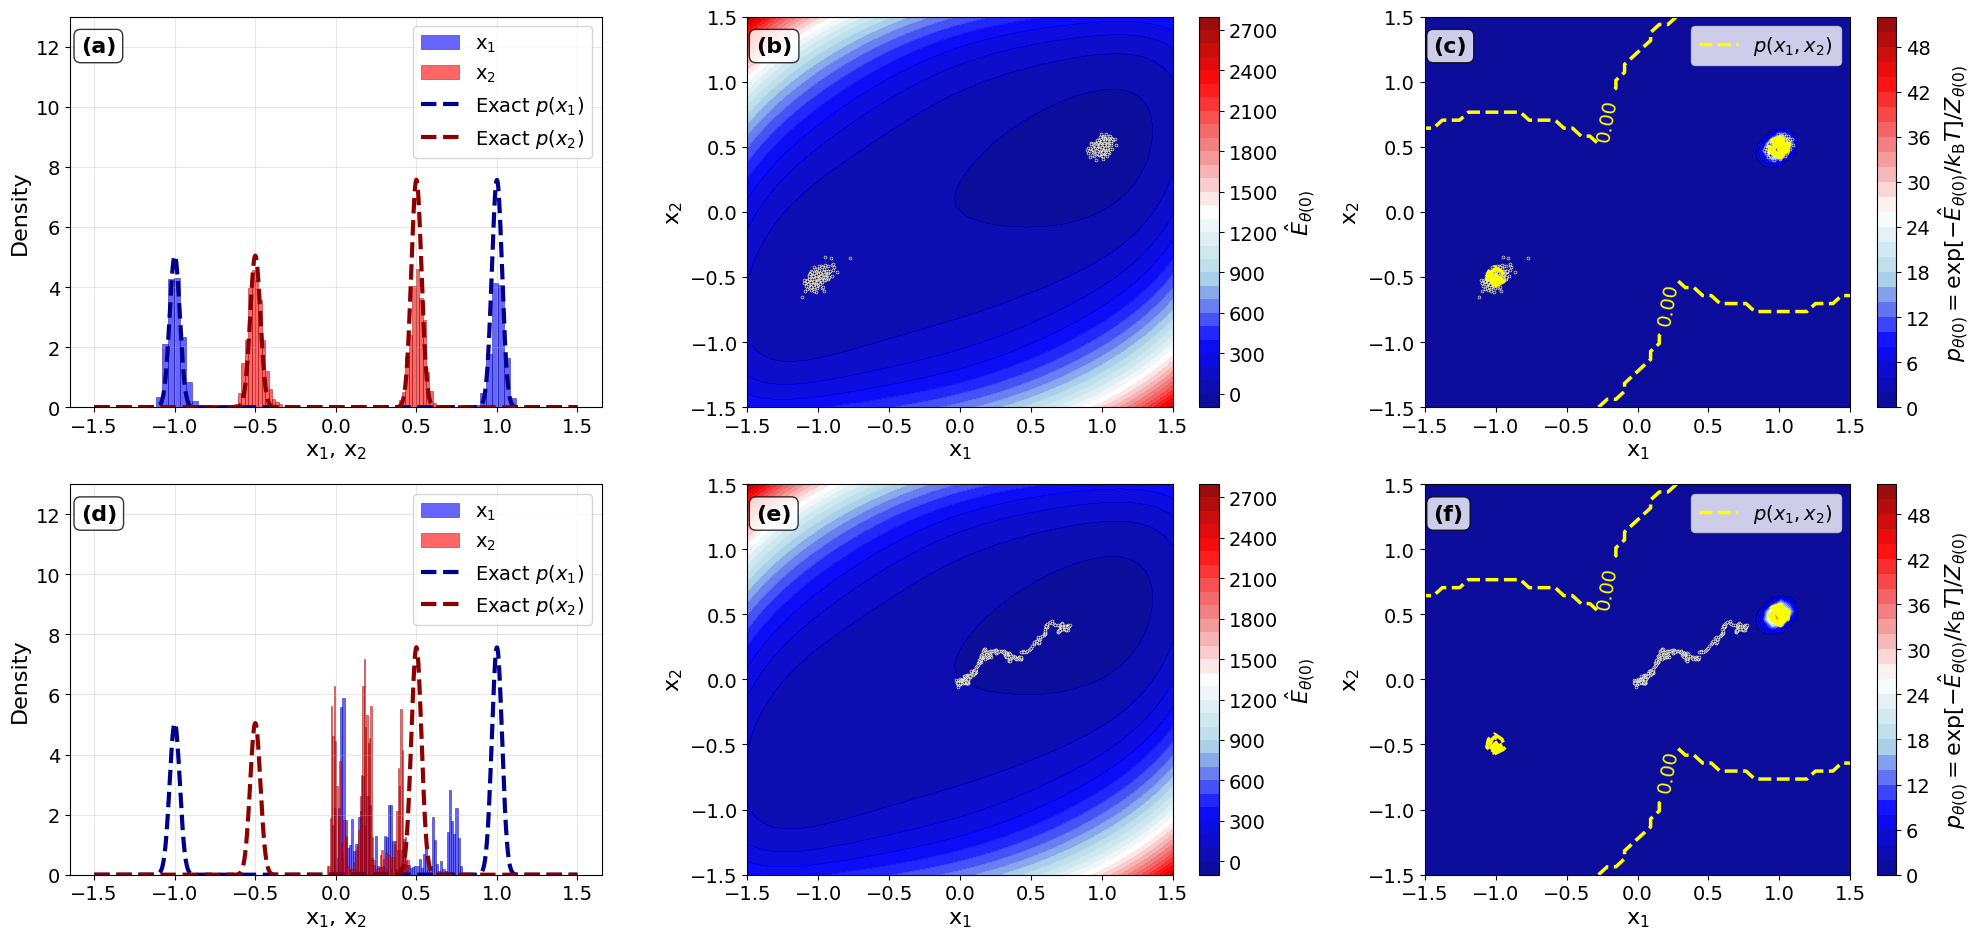

In [15]:
plot_sampels_energy_marginals_for_SGM_vs_ES(
    energy_fn,
    params_interpolator(0)/Temp,
    params_interpolator(0)/Temp,
    final_states,
    sde_samples_direct,
    weights, means, covs,
    n_points=50,
    num_bins=60,
    sample_stride=5,
    x1_range=(-1.5,1.5),
    x2_range=(-1.5,1.5),
    figsize=(20,10),
    fontsize=16,
    label_fontsize=16,
    iso_levels=7,
    colormap='bwr',
    contour_linewidth=2.5,
    scatter_size=4,
    scatter_alpha=0.9,
    plot_folder=plot_folder,
    n_trajectories=n_trajectories,
    atol=atol,
    rtol=rtol,
    Temp=Temp
)


In [16]:
# Estimate the covariance matrix from the final state samples
estimated_mean = jnp.mean(final_states, axis=0)
estimated_cov = jnp.cov(final_states.T)

# Theoretical covariance of the Gaussian mixture:
# μ_total = Σ_k w_k μ_k
# Σ_total = Σ_k w_k (Σ_k + μ_k μ_k^T) - μ_total μ_total^T
theoretical_mean = jnp.sum(weights[:, None] * means, axis=0)
theoretical_cov = sum(
    weights[k] * (covs[k] + jnp.outer(means[k], means[k]))
    for k in range(len(weights))
) - jnp.outer(theoretical_mean, theoretical_mean)

print("=== Mean ===")
print(f"  Estimated:   {estimated_mean}")
print(f"  Theoretical: {theoretical_mean}")
print()
print("=== Covariance Matrix ===")
print("  Estimated:")
print(f"    {estimated_cov}")
print("  Theoretical:")
print(f"    {theoretical_cov}")
print()
print("=== Element-wise relative error ===")
rel_err = jnp.abs(estimated_cov - theoretical_cov) / jnp.abs(theoretical_cov)
print(f"    {rel_err}")

=== Mean ===
  Estimated:   [-0.0725588  -0.03470068]
  Theoretical: [0.2 0.1]

=== Covariance Matrix ===
  Estimated:
    [[0.99860061 0.50200574]
 [0.50200574 0.25393036]]
  Theoretical:
    [[0.961 0.48 ]
 [0.48  0.241]]

=== Element-wise relative error ===
    [[0.03912654 0.0458453 ]
 [0.0458453  0.05365295]]


## Temperature as a hyperparameter

In [17]:
import json

# Assign each sample to its nearest theoretical mean (hard clustering)
n_components = len(weights)
dists = jnp.stack([jnp.sum((final_states - means[k]) ** 2, axis=1) for k in range(n_components)], axis=1)
assignments = jnp.argmin(dists, axis=1)

errors_record = {"Temp": float(Temp), "components": []}

print("=== Per-component Gaussian estimation (nearest-mean clustering) ===\n")
for k in range(n_components):
    mask = assignments == k
    cluster_samples = final_states[mask]
    n_k = jnp.sum(mask)

    w_est = float(n_k / len(final_states))
    mu_est = jnp.mean(cluster_samples, axis=0)
    cov_est = jnp.cov(cluster_samples.T)
    cov_th = covs[k]

    abs_err_weight = abs(w_est - float(weights[k]))
    abs_err_mean = jnp.abs(mu_est - means[k])
    abs_err_cov = jnp.abs(cov_est - cov_th)

    errors_record["components"].append({
        "weight_abs_err": float(abs_err_weight),
        "mean_abs_err": [float(v) for v in abs_err_mean],
        "cov_abs_err": [[float(v) for v in row] for row in abs_err_cov],
    })

    print(f"--- Component {k+1} (n={int(n_k)}) ---")
    print(f"  Weight:     {w_est:.6f}  (theoretical: {float(weights[k]):.6f})")
    print(f"  Mean:       {mu_est}  (theoretical: {means[k]})")
    print(f"  Covariance:")
    print(f"    Estimated:   {cov_est}")
    print(f"    Theoretical: {cov_th}")
    print(f"  Absolute errors:")
    print(f"    Weight: {abs_err_weight:.6f}")
    print(f"    Mean:   {abs_err_mean}")
    print(f"    Cov:    {abs_err_cov}")
    print()

# Also store the mixture-level absolute errors from the previous cell
errors_record["mixture"] = {
    "mean_abs_err": [float(v) for v in jnp.abs(estimated_mean - theoretical_mean)],
    "cov_abs_err": [[float(v) for v in row] for row in jnp.abs(estimated_cov - theoretical_cov)],
}

# Save to a temperature-independent directory so data accumulates across runs
errors_dir = os.path.join(base_dir, current_date, f"gaussian_mixture/Energy_fn_type_6th_order_local_duffing_coupling_Temp_{Temp}")
os.makedirs(errors_dir, exist_ok=True)
errors_file = os.path.join(errors_dir, "estimation_errors_vs_temp.jsonl")

# Load existing records, update/add the current temperature, write back
existing = {}
if os.path.exists(errors_file):
    with open(errors_file, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                rec = json.loads(line)
                existing[rec["Temp"]] = rec

existing[errors_record["Temp"]] = errors_record

with open(errors_file, "w") as f:
    for temp_key in sorted(existing.keys()):
        f.write(json.dumps(existing[temp_key]) + "\n")

print(f"Saved errors for Temp={Temp} to {errors_file}")
print(f"File now contains {len(existing)} temperature point(s): {sorted(existing.keys())}")

=== Per-component Gaussian estimation (nearest-mean clustering) ===

--- Component 1 (n=927) ---
  Weight:     0.463500  (theoretical: 0.600000)
  Mean:       [1.00128213 0.50521729]  (theoretical: [1.  0.5])
  Covariance:
    Estimated:   [[0.00157314 0.00047995]
 [0.00047995 0.00162322]]
    Theoretical: [[0.001 0.   ]
 [0.    0.001]]
  Absolute errors:
    Weight: 0.136500
    Mean:   [0.00128213 0.00521729]
    Cov:    [[0.00057314 0.00047995]
 [0.00047995 0.00062322]]

--- Component 2 (n=1073) ---
  Weight:     0.536500  (theoretical: 0.400000)
  Mean:       [-1.0002853  -0.50115357]  (theoretical: [-1.  -0.5])
  Covariance:
    Estimated:   [[0.00213108 0.00118716]
 [0.00118716 0.00224915]]
    Theoretical: [[0.001 0.   ]
 [0.    0.001]]
  Absolute errors:
    Weight: 0.136500
    Mean:   [0.0002853  0.00115357]
    Cov:    [[0.00113108 0.00118716]
 [0.00118716 0.00124915]]

Saved errors for Temp=0.2 to ../out/problems/2026_02_19/gaussian_mixture/Energy_fn_type_6th_order_local_du

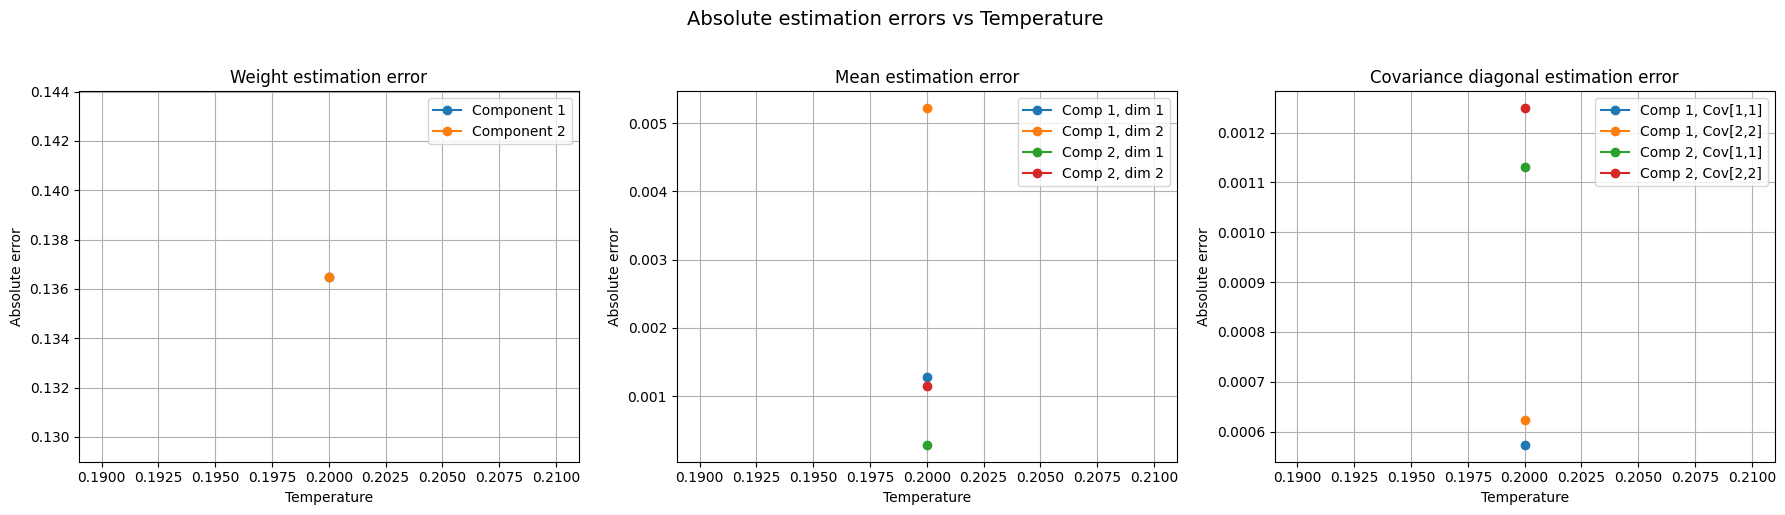

Loaded 1 temperature point(s): [0.2]


In [18]:
import json
import numpy as np

errors_dir = os.path.join(base_dir, current_date, f"gaussian_mixture/Energy_fn_type_6th_order_local_duffing_coupling_Temp_{Temp}")
errors_file = os.path.join(errors_dir, "estimation_errors_vs_temp.jsonl")

records = []
with open(errors_file, "r") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

# De-duplicate: keep the last entry per temperature
seen = {}
for r in records:
    seen[r["Temp"]] = r
records = sorted(seen.values(), key=lambda r: r["Temp"])

temps = np.array([r["Temp"] for r in records])
n_components = len(records[0]["components"])
dim = len(records[0]["components"][0]["mean_abs_err"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Weight errors ---
ax = axes[0]
for k in range(n_components):
    errs = [r["components"][k]["weight_abs_err"] for r in records]
    ax.plot(temps, errs, "o-", label=f"Component {k+1}")
ax.set_xlabel("Temperature")
ax.set_ylabel("Absolute error")
ax.set_title("Weight estimation error")
ax.legend()
ax.grid(True)

# --- Mean errors (per dimension) ---
ax = axes[1]
for k in range(n_components):
    for d in range(dim):
        errs = [r["components"][k]["mean_abs_err"][d] for r in records]
        ax.plot(temps, errs, "o-", label=f"Comp {k+1}, dim {d+1}")
ax.set_xlabel("Temperature")
ax.set_ylabel("Absolute error")
ax.set_title("Mean estimation error")
ax.legend()
ax.grid(True)

# --- Covariance errors (diagonal elements) ---
ax = axes[2]
for k in range(n_components):
    for d in range(dim):
        errs = [r["components"][k]["cov_abs_err"][d][d] for r in records]
        ax.plot(temps, errs, "o-", label=f"Comp {k+1}, Cov[{d+1},{d+1}]")
ax.set_xlabel("Temperature")
ax.set_ylabel("Absolute error")
ax.set_title("Covariance diagonal estimation error")
ax.legend()
ax.grid(True)

fig.suptitle("Absolute estimation errors vs Temperature", fontsize=14, y=1.02)
fig.tight_layout()
plt.savefig(os.path.join(plot_folder, "estimation_errors_vs_temp.png"), dpi=300, bbox_inches="tight")
plt.show()

print(f"Loaded {len(records)} temperature point(s): {temps}")